In [53]:
#1.NDEKUPE, SHABANI HUSSEIN30554/T.2023
#2.NANYARO, RONARD EMMANUEL32099/T.2023
3.MWAITUKA, STEPHEN ANYIGULILE32143/T.2023
4.MPAMBIJE, VICTOR SOSTENES32162/T.2023
5.IDDY, IDDY SAIDI31524/T.2023
6.JEREMIA, KURUTHUM SAID31334/T.2023



# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("loanapproval.csv")

# Display first five records
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1
5,6,41,Male,Married,53848,13036,594,3,4,Unemployed,0


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   applicant_id          1000 non-null   int64
 1   age                   1000 non-null   int64
 2   gender                1000 non-null   str  
 3   marital_status        1000 non-null   str  
 4   annual_income         1000 non-null   int64
 5   loan_amount           1000 non-null   int64
 6   credit_score          1000 non-null   int64
 7   num_dependents        1000 non-null   int64
 8   existing_loans_count  1000 non-null   int64
 9   employment_status     1000 non-null   str  
 10  loan_approved         1000 non-null   int64
dtypes: int64(8), str(3)
memory usage: 86.1 KB


In [20]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

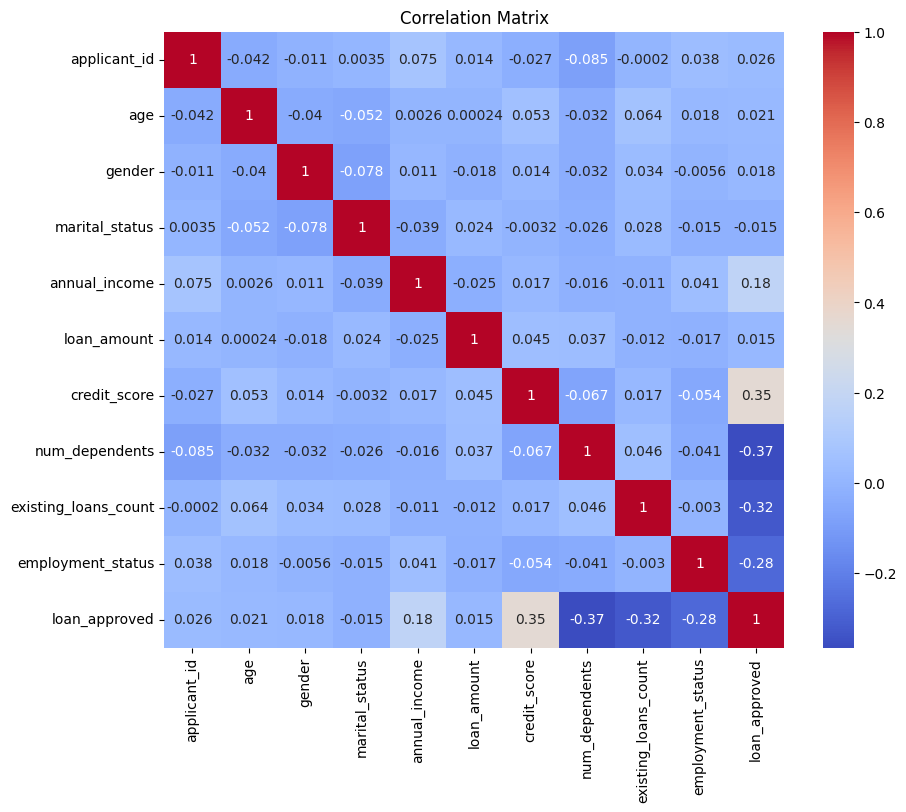

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [28]:
X = df.drop("loan_approved", axis=1)
y = df["loan_approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (700, 10)
Testing size: (300, 10)


In [30]:
df = pd.read_csv("loanapproval.csv")

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [38]:
X = df.drop("loan_approved", axis=1)
y = df["loan_approved"]

In [39]:
print(y.unique())
print(y.dtype)

[1 0]
int64


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8633333333333333


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, confusion_matrix, classification_report
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("RMSE:", rmse)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8633333333333333
Precision: 0.9045454545454545
Recall: 0.908675799086758
RMSE: 0.3696845502136472

Confusion Matrix:
 [[ 60  21]
 [ 20 199]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.74      0.75        81
           1       0.90      0.91      0.91       219

    accuracy                           0.86       300
   macro avg       0.83      0.82      0.83       300
weighted avg       0.86      0.86      0.86       300



In [46]:
new_applicant = X_test[0:1]   # Taking one sample from test set
prediction = model.predict(new_applicant)

print("Prediction:", prediction)

Prediction: [0]


In [49]:
print(df.isnull().sum())

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64
